# 03. 교육 플랫폼 사용자 이탈 예측 

In [120]:
# 라이브러리 임포트
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [148]:
# 데이터 파일 읽어오기
edu_df = pd.read_csv('C:/juehyeon/aice_test/materials/datasets/edu_users.csv')

In [149]:
# 데이터 파악 
edu_df.describe()

,rate_math,rate_science,rate_english,rate_humanities,rate_art,tot_time,age,leave_yn
count,1188.000000,1188.000000,1250.000000,1250.000000,1250.00000,1188.000000,1250.000000,1250.000000
mean,0.496497,0.499140,0.497136,0.492422,0.49503,29.708603,34.329600,0.308800
std,0.293143,0.288396,0.289979,0.286959,0.28964,10.063217,14.574241,0.462183
min,0.005000,0.002000,0.000000,0.000000,0.00400,1.000000,10.000000,0.000000
25%,0.237750,0.248500,0.247000,0.243000,0.24300,22.882500,22.000000,0.000000
50%,0.504000,0.506000,0.499500,0.484000,0.48950,29.745000,34.000000,0.000000
75%,0.753500,0.737000,0.751000,0.738000,0.74200,36.442500,47.000000,1.000000
max,0.998000,0.999000,1.000000,0.998000,0.99900,61.130000,59.000000,1.000000


In [150]:
edu_df.head()

,rate_math,rate_science,rate_english,rate_humanities,rate_art,tot_time,device,gender,age,resub_yn,comb_yn,othersub_yn,leave_yn
0,0.375,0.797,0.828,0.896,0.394,17.09,mobile,M,30,N,N,Y,1
1,0.951,0.482,0.765,0.909,0.473,28.57,tablet,F,25,N,Y,N,1
2,0.732,0.117,0.574,0.314,0.855,40.97,tablet,F,24,N,N,N,0
3,0.599,0.125,0.956,0.691,0.340,8.09,mobile,M,14,Y,N,N,1
4,0.156,0.686,0.200,0.272,0.870,45.34,tablet,F,15,Y,N,N,0


In [151]:
# 결측치 파악하기
edu_df.info() # 전체 행 : 1250 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1250 entries, 0 to 1249
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   rate_math        1188 non-null   float64
 1   rate_science     1188 non-null   float64
 2   rate_english     1250 non-null   float64
 3   rate_humanities  1250 non-null   float64
 4   rate_art         1250 non-null   float64
 5   tot_time         1188 non-null   float64
 6   device           1250 non-null   object 
 7   gender           1250 non-null   object 
 8   age              1250 non-null   int64  
 9   resub_yn         1250 non-null   object 
 10  comb_yn          1250 non-null   object 
 11  othersub_yn      1250 non-null   object 
 12  leave_yn         1250 non-null   int64  
dtypes: float64(6), int64(2), object(5)
memory usage: 127.1+ KB


## 해석
1. rate_math, rate_science, tot_time은 결측치가 존재한다. -> non-null count : 1188이므로, 결측치는 1250 - 1188 = 62개
2. device, gender, resub_yn, comb)yn, othersub_yn은 범주형 변수이지만, dtype은 모두 object로 표시된다. 
3. 전체 열은 13개이며, 이 중 수치형 변수는 총 8개이다. 
4. leave_yn은 이탈 여부를 나타내는 이진 분류형 변수이며, 수치형(int64)으로 저장되어 있다. 

In [152]:
# 상관관계 파악하기
## corr_list 변수 생성
corr_list = ['rate_math', 'rate_science', 'rate_english', 'rate_humanities', 'rate_art']
## 상관관계 파악하기
correlation_matrix = edu_df[corr_list].corr()
correlation_matrix

,rate_math,rate_science,rate_english,rate_humanities,rate_art
rate_math,1.000000,-0.049638,0.006031,0.001535,-0.037954
rate_science,-0.049638,1.000000,0.021276,0.056940,-0.019499
rate_english,0.006031,0.021276,1.000000,0.025619,-0.014633
rate_humanities,0.001535,0.056940,0.025619,1.000000,-0.003499
rate_art,-0.037954,-0.019499,-0.014633,-0.003499,1.000000


<Axes: >

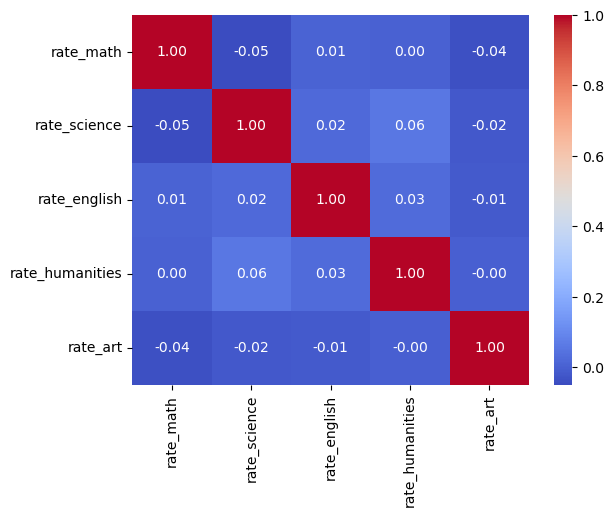

In [153]:
## corr_list 활용하여 heat map으로 시각화하기 
sns.heatmap(
    data = edu_df[corr_list].corr(),  
    annot = True, # 셀에 숫자 표시 
    cmap = 'coolwarm', # 색상 팔레트
    cbar = True,  # 상관관계 막대기 
    fmt = '.2f')  # 자릿수 표현 

## 해석 
1. rate_math와 rate_science는 상관계수가 -0.05로 다소 낮다. 
2. rate_english, rate_humanities는 0.03으로 약한 양의 상관관계를 가진다.
3. rate_art와 다른 과목들은 대체로 음의 상관관계를 가진다.
4. 전체 과목 간 상관 계수는 모두 절댓값 0.06이하로 뚜렷한 상관 관계 없이 독립적인 성향을 가진다. 

평균값: 
leave_yn
0    30.100378
1    28.832180
Name: tot_time, dtype: float64


<Axes: xlabel='leave_yn', ylabel='tot_time'>

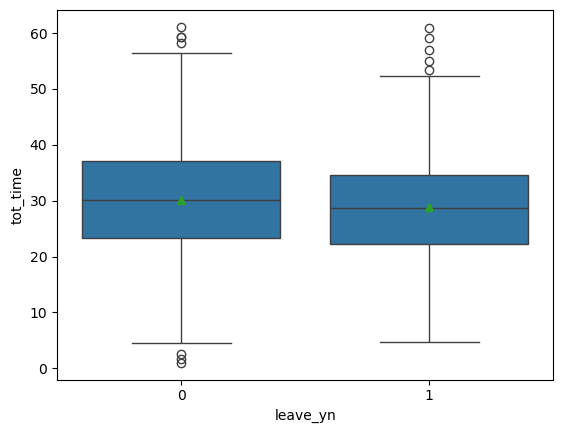

In [154]:
# 이탈 여부에 따른 학습 시간의 분포 시각화 
## box_plot 그리기
print(f'평균값: \n{edu_df.groupby('leave_yn')['tot_time'].mean()}')# 평균값 확인하기
sns.boxplot(data = edu_df, x = 'leave_yn', y = 'tot_time', showmeans = True) #showmeans -> 평균값 표현 


## 해석
1. 유지 사용자(0)은 이탈 사용자(1)보다 평균 학습 시간이 길고, 이상치도 이탈 사용자보다 많다.
2. 이탈 사용자(1)의 중앙 값은 유지 사용자(0)보다 낮다.
3. 유지 사용자(0)의 학습 시간 분포가 더 넓고 이상치도 더 많이 존재한다.
4. 두 그룹 모두 중앙값은 유사하나, 이탈 사용자(1)는 상단에만 이상치가 집중되어 있어 이상치 분포 양상에 차이가 있다.

In [155]:
# 이탈 여부에 따라 평균 시청률 변화 분석하기
## 이탈여부로 rate_math, rate_science의 평균을 pivot_table로 만들기
pivot_df = edu_df.pivot_table(
    index = 'leave_yn',
    values = ['rate_math', 'rate_science'],
    aggfunc = 'mean'
)
## 확인
pivot_df

,rate_math,rate_science
leave_yn,,
0,0.487965,0.496375
1,0.515511,0.505424


In [156]:
# 결측치 처리하기
## 결측치 확인하기
edu_df['rate_math'].isnull().sum() #결측치 처리 전 : 62

np.int64(62)

In [157]:
## 결측치 평균으로 채우기
edu_df['rate_math'] = edu_df['rate_math'].fillna(edu_df['rate_math'].mean())

In [158]:
## 결측치 처리 확인
edu_df['rate_math'].isnull().sum() #결측치 처리 후 : 0

np.int64(0)

In [159]:
## rate_science 결측치 확인
edu_df['rate_science'].isna().sum() # 결측치 처리 전 : 62

np.int64(62)

In [160]:
## 결측치 중앙값으로 채우기 
edu_df['rate_science'] = edu_df['rate_science'].fillna(edu_df['rate_science'].median())

In [161]:
## 결측치 처리 확인
edu_df['rate_science'].isna().sum() # 결측치 처리 후 : 0

np.int64(0)

In [162]:
## tot_time 결측치 확인
edu_df['tot_time'].isna().sum() # 결측치 처리 전: 62

np.int64(62)

In [163]:
## 결측치 최빈값으로 채우기
edu_df['tot_time'] = edu_df['tot_time'].fillna(edu_df['tot_time'].mode()[0]) ##최빈값은 꼭 [0] 붙이기 ! 

In [164]:
## 결측치 처리 확인
edu_df['tot_time'].isna().sum() # 결측치 처리 후 : 0

np.int64(0)

In [165]:
## 라이브러리 임포트하기 - train_test_split
from sklearn.model_selection import train_test_split

In [166]:
## 범주형 변수 인코딩하기
## 원핫 인코딩
cols = ['device', 'gender', 'resub_yn', 'comb_yn', 'othersub_yn']
edu_df = pd.get_dummies(data = edu_df, columns = cols, drop_first = True)

In [192]:
# 데이터 분리하기
## X, y 데이터 분리
X = edu_df[['rate_math', 'rate_science', 'rate_english', 'tot_time']]
y = edu_df['leave_yn']

In [193]:
## 훈련, 검증 데이터셋 분리 (순서 조심) 
X_train, X_valid, y_train, y_valid = train_test_split(X, y, random_state = 42, test_size = 0.2)
## 확인하기
print(X_train.shape, X_valid.shape, y_train.shape, y_valid.shape)

(1000, 4) (250, 4) (1000,) (250,)


In [194]:
## 확인 결과 X_train, X_valid는 (행수, 피처개수) , y_train와 y_valid는 (행수,)만 있으니 확인 습관화할 것

In [195]:
# 데이터 스케일링하기 
## 라이브러리 임포트
from sklearn.preprocessing import StandardScaler

In [196]:
## 모델 객체 생성
scaler = StandardScaler()

In [197]:
## Feature 데이터 스케일링 
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_valid)

In [198]:
# RandomForestClassifier 모델 학습
## 라이브러리 임포트
from sklearn.ensemble import RandomForestClassifier

In [199]:
## 모델 객체 생성
rfc = RandomForestClassifier(n_estimators = 150, max_depth = 7, min_samples_split = 5, random_state = 42)

In [200]:
## 모델 학습
rfc.fit(X_train, y_train)

,n_estimators,150
,criterion,'gini'
,max_depth,7
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [201]:
# XGBoost 모델 학습
## 라이브러리 임포트 
from xgboost import XGBClassifier

In [202]:
## 모델 객체 생성
xgbc = XGBClassifier(n_estimators = 200, max_depth = 5, learning_rate = 0.1, random_state = 42) 

In [203]:
xgbc.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [204]:
# accuracy, f1 score 비교
## 라이브러리 임포트
from sklearn.metrics import accuracy_score, f1_score

In [205]:
## 검증 데이터 예측 
rfc_predict = rfc.predict(X_test) 
xgbc_predict = xgbc.predict(X_test) 

In [206]:
## accuracy 확인하기
rfc_accuracy = accuracy_score(y_valid, rfc_predict)
xgbc_accuracy = accuracy_score(y_valid, xgbc_predict)
print(f'rfc_accuracy : {rfc_accuracy}')
print(f'xgbc_accuracy : {xgbc_accuracy}')

rfc_accuracy : 0.632
xgbc_accuracy : 0.64


In [207]:
## f1_score 확인하기
rfc_f1_score = f1_score(y_valid, rfc_predict)
xgbc_f1_score = f1_score(y_valid, xgbc_predict)
print(f'rfc_f1 score : {rfc_f1_score}')
print(f'xgbc_f1 score : {xgbc_f1_score}')

rfc_f1 score : 0.02127659574468085
xgbc_f1 score : 0.2857142857142857


In [208]:
## xgbc의 정확도가 더 높음.  

In [209]:
# 딥러닝 모델 학습 - Sequential
## 라이브러리 임포트
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input, BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
tf.random.set_seed(10)

In [212]:
## 모델 생성
dl_model = Sequential([
    Input(shape=(X_train.shape[1], )),
    Dense(64, activation = 'selu'),
    BatchNormalization(),
    Dense(32, activation = 'selu'),
    BatchNormalization(),
    Dense(16, activation = 'selu'),
    Dense(1, activation = 'sigmoid')
])

In [215]:
## 모델 컴파일
dl_model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

In [217]:
dl_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,329 (13.00 KB)

 Trainable params: 3,137 (12.25 KB)

 Non-trainable params: 192 (768.00 B)

In [218]:
history = dl_model.fit(
    X_train, y_train, 
    epochs = 45,
    batch_size = 32
)
    

Epoch 1/45
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5820 - loss: 0.7131
Epoch 2/45
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6700 - loss: 0.6321
Epoch 3/45
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6840 - loss: 0.6189
Epoch 4/45
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6910 - loss: 0.6126
Epoch 5/45
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6970 - loss: 0.6080
Epoch 6/45
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6970 - loss: 0.6039
Epoch 7/45
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6980 - loss: 0.6005
Epoch 8/45
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7010 - loss: 0.5979
Epoch 9/45
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7000 - loss: 0.5959
Epoch 10/45
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7010 - loss: 0.5944
Epoch 11/45
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7000 - loss: 0.5926
Epoch 12/45
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7000 - lo

In [219]:
# 딥러닝 모델로 예측하기
## 시뮬 데이터 생성
simul_data = np.array([[0.3, 0.5, 0.7, 120]]) 

In [220]:
## 예측 결과 출력하기
deep_predict = dl_model.predict(simul_data)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step


In [222]:
## 0.5기준으로 미만이면 0, 이상이면 1로 
np.where(deep_predict>=0.5, 1, 0) 

array([[0]])